# Experiment C — Adaptive Online LQR

Comparison of **Frank–Wolfe**, **CE + Naive**, and **Sampling**. 



## Dynamics, information matrices, and data tools

| Function | Purpose |
|---|---|
| `block_diag_np` | Builds joint state–input matrices such as `blkdiag(Q, R)`. |
| `dare_solve` | Computes an infinite-horizon Riccati solution and CE gain. |
| `finite_horizon_lqr_gains` | Returns a safe time-varying finite-horizon gain sequence. |
| `solve_discrete_lyapunov_np` | Solves the discrete Lyapunov equation iteratively. |
| `riccati_iteration` | Alternative infinite-horizon Riccati iteration used by the experiment. |
| `lqr_cost_fixed_theta` | Evaluates a fixed gain on a fixed estimated model. |
| `solve_lqr_with_noise_feasibility` | Generalized finite-horizon Riccati sweep with admissibility checks. |
| `compute_cost_and_covariance` | Propagates joint moments and evaluates their weighted cost. |
| `_finite_difference_jacobian` | Computes a central-difference Jacobian. |
| `_finite_difference_hessian` | Computes a central-difference Hessian. |
| `hessian_CE` | Builds the certainty-equivalent task Hessian. |

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def block_diag_np(*arrays):
    """Construct a block-diagonal matrix using NumPy."""
    shapes = np.array([a.shape for a in arrays])
    rows = int(shapes[:, 0].sum())
    cols = int(shapes[:, 1].sum())
    out = np.zeros((rows, cols), dtype=arrays[0].dtype)
    r, c = 0, 0
    for a in arrays:
        rr, cc = a.shape
        out[r:r+rr, c:c+cc] = a
        r += rr
        c += cc
    return out


def dare_solve(A, B, Q, R, tol=1e-10, max_iters=10_000):
    """
    Solve the discrete-time algebraic Riccati equation (DARE) via value iteration.
    Converges if (A, B) stabilizable and (A, Q^0.5) detectable.
    """
    def next_P(P):
        BtPB = B.T @ P @ B
        BtPA = B.T @ P @ A
        K = np.linalg.solve(R + BtPB, BtPA)
        Pn = Q + A.T @ P @ A - (A.T @ P @ B) @ K
        return 0.5 * (Pn + Pn.T)

    P = Q.copy()
    P_prev = P + 10 * tol * np.eye(Q.shape[0], dtype=Q.dtype)
    i = 0
    while np.linalg.norm(P - P_prev, ord='fro') > tol and i < max_iters:
        P_next = next_P(P)
        P_prev = P
        P = P_next
        i += 1

    BtPB = B.T @ P @ B
    BtPA = B.T @ P @ A
    K = np.linalg.solve(R + BtPB, BtPA)
    return P, K


def finite_horizon_lqr_gains(A, B, Q, R, T):
    """Return time-varying gains K_0,...,K_{T-1} from a zero terminal cost."""
    P = np.zeros_like(Q)
    gains_reversed = []
    for _ in range(int(T)):
        K = np.linalg.solve(R + B.T @ P @ B, B.T @ P @ A)
        P = Q + A.T @ P @ A - (A.T @ P @ B) @ K
        P = 0.5 * (P + P.T)
        gains_reversed.append(K)
    return np.asarray(gains_reversed[::-1])


def solve_discrete_lyapunov_np(A, Q, max_iter=1000, tol=1e-8):
    P = Q
    for _ in range(max_iter):
        P_next = A.T @ P @ A + Q
        if np.linalg.norm(P_next - P) < tol:
            break
        P = P_next
    return P


def riccati_iteration(A, B, Q, R, max_iter=1000, tol=1e-8):
    P = Q.copy()
    for _ in range(max_iter):
        S = R + B.T @ P @ B
        K = np.linalg.solve(S, B.T @ P @ A)
        P_next = Q + A.T @ P @ A - A.T @ P @ B @ K
        if np.linalg.norm(P_next - P) < tol:
            P = P_next
            break
        P = P_next
    # Final optimal gain
    K_opt = np.linalg.solve(R + B.T @ P @ B, B.T @ P @ A)
    return P, K_opt


def lqr_cost_fixed_theta(K, A_hat, B_hat, Q, R, Sigma_w, T):
    A_cl = A_hat - B_hat @ K      # K can be (m,n)
    Q_bar = Q + K.T @ R @ K
    P = solve_discrete_lyapunov_np(A_cl.T, Q_bar)
    
    # Handle scalar T
    if np.ndim(T) == 0:
        return T * np.trace(P @ Sigma_w)
    else:
        return np.trace(T @ P @ Sigma_w)


def solve_lqr_with_noise_feasibility(A, B, M_seq, Sigma_w, x0=None):
    """
    Finite-horizon LQR with backward Riccati sweep, process noise, and feasibility checks.
    M_seq[t] = [[Q_t, S_t],[S_t^T, R_t]]
    """
    T, n, m = M_seq.shape[0], A.shape[0], B.shape[1]

    P_next = np.zeros((n, n), dtype=A.dtype)
    feasible = True
    K_rev = []
    P_rev = []
    c_rev = []

    for M_t in M_seq[::-1]:
        Q, S, R = M_t[:n, :n], M_t[:n, n:], M_t[n:, n:]

        BtPB = B.T @ P_next @ B
        BtPA = B.T @ P_next @ A
        R_tilde = R + BtPB

        eig_min = np.min(np.linalg.eigvalsh(R_tilde))
        # Lemma 3 requires strict positive definiteness.
        is_step_feasible = eig_min > 1e-9
        feasible = bool(feasible and is_step_feasible)

        if is_step_feasible:
            K_t = np.linalg.solve(R_tilde, BtPA + S.T)
        else:
            K_t = np.zeros((m, n), dtype=A.dtype)

        AK = A - B @ K_t
        P_t = Q + K_t.T @ R @ K_t - (S @ K_t + K_t.T @ S.T) + AK.T @ P_next @ AK 
        P_t = 0.5 * (P_t + P_t.T)
        c_t = np.trace(P_next @ Sigma_w)

        K_rev.append(K_t)
        P_rev.append(P_t)
        c_rev.append(c_t)
        P_next = P_t

    P_T = np.zeros((n, n), dtype=A.dtype)
    K_list = np.asarray(K_rev[::-1], dtype=A.dtype)
    P_list = np.concatenate([np.asarray(P_rev[::-1], dtype=A.dtype), P_T[np.newaxis]], axis=0)
    c_list = np.concatenate([np.asarray(c_rev[::-1], dtype=A.dtype), np.zeros((1,), dtype=A.dtype)], axis=0)

    J_star = None if x0 is None else x0 @ P_list[0] @ x0 + c_list[0]
    return K_list, P_list, c_list, J_star, feasible


def compute_cost_and_covariance(A, B, K_list, Sigma_w, T, W, Sigma_x0=None):
    """Compute cumulative LQR cost and covariance trajectory."""
    n = A.shape[0]

    # Start from the episode's current state second moment.
    Sigma_x = Sigma_w.copy() if Sigma_x0 is None else np.asarray(Sigma_x0).copy()
    Sigma_z_seq = []
    for K in K_list:
        A_cl = A - B @ K
        Sigma_u = K @ Sigma_x @ K.T
        Sigma_xu = -Sigma_x @ K.T
        Sigma_z = np.block([[Sigma_x, Sigma_xu],
                            [Sigma_xu.T, Sigma_u]])
        Sigma_x_next = A_cl @ Sigma_x @ A_cl.T + Sigma_w
        Sigma_x = 0.5 * (Sigma_x_next + Sigma_x_next.T)
        Sigma_z_seq.append(Sigma_z)

    Sigma_z_seq = np.asarray(Sigma_z_seq, dtype=A.dtype)
    sum_cov = np.sum(Sigma_z_seq, axis=0)
    total_cost = np.trace(W @ sum_cov)
    return total_cost, Sigma_z_seq


def _finite_difference_jacobian(fun, x, eps=1e-5):
    x = np.asarray(x, dtype=float)
    f0 = np.asarray(fun(x), dtype=float).reshape(-1)
    J = np.zeros((f0.size, x.size), dtype=float)
    for i in range(x.size):
        dx = np.zeros_like(x)
        dx[i] = eps
        fp = np.asarray(fun(x + dx), dtype=float).reshape(-1)
        fm = np.asarray(fun(x - dx), dtype=float).reshape(-1)
        J[:, i] = (fp - fm) / (2.0 * eps)
    return J


def _finite_difference_hessian(fun, x, eps=1e-4):
    x = np.asarray(x, dtype=float)
    d = x.size
    H = np.zeros((d, d), dtype=float)
    f0 = float(fun(x))
    for i in range(d):
        ei = np.zeros_like(x)
        ei[i] = eps
        fpi = float(fun(x + ei))
        fmi = float(fun(x - ei))
        H[i, i] = (fpi - 2.0 * f0 + fmi) / (eps**2)
        for j in range(i + 1, d):
            ej = np.zeros_like(x)
            ej[j] = eps
            fpp = float(fun(x + ei + ej))
            fpm = float(fun(x + ei - ej))
            fmp = float(fun(x - ei + ej))
            fmm = float(fun(x - ei - ej))
            Hij = (fpp - fpm - fmp + fmm) / (4.0 * eps**2)
            H[i, j] = Hij
            H[j, i] = Hij
    return H


def hessian_CE(A_hat, B_hat, Q, R, Sigma_w, T):
    n, m = B_hat.shape[0], B_hat.shape[1]

    # compute K_hat
    _, K_hat = riccati_iteration(A_hat, B_hat, Q, R)

    # Hessian of J w.r.t K (A_hat, B_hat fixed)
    # K_hat kept as (m,n) shape
    K_hat_vec = K_hat.flatten()
    H_K = _finite_difference_hessian(
        lambda K_vec: lqr_cost_fixed_theta(K_vec.reshape(m, n), A_hat, B_hat, Q, R, Sigma_w, T),
        K_hat_vec,
    )

    # Jacobian of K w.r.t theta = vec(A,B)
    def K_fn(theta_vec):
        A = theta_vec[:n*n].reshape(n, n)
        B = theta_vec[n*n:].reshape(n, m)
        _, K_theta = riccati_iteration(A, B, Q, R)
        return K_theta.flatten()

    theta_hat_vec = np.concatenate([A_hat.flatten(), B_hat.flatten()])
    J_K_theta = _finite_difference_jacobian(K_fn, theta_hat_vec)  # shape (m*n, d)

    # Chain-rule Hessian
    H_CE = J_K_theta.T @ H_K @ J_K_theta
    return H_CE


## Frank–Wolfe planning

| Function | Purpose |
|---|---|
| `make_costs_fun` | Builds corrected FW stage costs using causal weights and exclusive moments. |
| `track_cumulative_covariances_naive_policy` | Predicts comparison-policy or candidate-policy cumulative moments. |
| `compute_objective_tau0` | Evaluates corrected objective (19). |
| `solve_subproblem` | Generic robust LMO with dual bisection and a safe fallback. |
| `frank_wolfe` | Repeatedly calls the LMO and updates the FW moment iterate. |

In [13]:
def make_costs_fun(T, tau, W_base, Inv_stack, H_hat, Sigma_w, k):
    """
    Construct the FW-linearized stage-cost matrices M_t for t in [tau[k], T).

    Implements

        M_t = W_base + sum_{m=k+1}^K 1{t <= tau_m} W_m^(i),

    where

        W_m^(i) =
            - (Lambda_k + tilde_Lambda_m^(i))^{-1}
              D_m
              (Lambda_k + tilde_Lambda_m^(i))^{-1},

        D_m = (tau_{m+1} - tau_m) * Tr_{Sigma_w}(H_hat).

    Convention:
        tau = [tau_0, ..., tau_K, tau_{K+1}=T]
        information terms use m = k+1, ..., K
        terminal time tau_{K+1}=T is excluded from information penalty
        controlled stages are t = tau[k], ..., T-1
    """
    tau = np.asarray(tau)
    Sigma_w = np.atleast_2d(Sigma_w)

    n = Sigma_w.shape[0]
    nxu = W_base.shape[0]

    # tau = [tau_0, ..., tau_K, tau_{K+1}=T]
    K_info_terminal = tau.shape[0] - 2
    L = K_info_terminal - k
    tau_k = int(tau[k])

    # Compute D_base = Tr_{Sigma_w}(H_hat), shape (nxu, nxu)
    H4 = H_hat.reshape(n, nxu, n, nxu)
    D_base = np.tensordot(Sigma_w, H4, axes=([0, 1], [0, 2]))
    D_base = 0.5 * (D_base + D_base.T)

    # Information update indices m = k+1, ..., K
    m_idx = np.arange(k + 1, K_info_terminal + 1, dtype=np.int32)

    # If no information terms remain, just return W_base over the remaining horizon
    times = np.arange(tau_k, T)
    Nt = times.shape[0]

    Wb = 0.5 * (W_base + W_base.T)
    base = np.broadcast_to(Wb, (Nt, nxu, nxu))

    if L <= 0:
        return base.copy()

    # pair update m with its following interval (tau_m, tau_{m+1}).
    deltas = (tau[m_idx + 1] - tau[m_idx]).astype(W_base.dtype)

    # W_m^(i) = - Inv_m D_m Inv_m
    W_info_stack = []
    for Inv_m, delta in zip(Inv_stack, deltas):
        X = Inv_m @ (delta * D_base) @ Inv_m
        W_info_stack.append(-0.5 * (X + X.T))

    W_info_stack = np.asarray(W_info_stack, dtype=W_base.dtype)

    # tau_m values for m = k+1, ..., K
    tau_m_arr = tau[m_idx]

    # information at tau_m uses stages strictly before tau_m.
    mask = (times[:, None] < tau_m_arr[None, :]).astype(W_base.dtype)

    sum_part = (
        mask[:, :, None, None] * W_info_stack[None, :, :, :]
    ).sum(axis=1)

    M_seq = base + sum_part
    M_seq = 0.5 * (M_seq + np.swapaxes(M_seq, -1, -2))

    return M_seq


def track_cumulative_covariances_naive_policy(
    A, B, A_rollout, B_rollout, Sigma_w, Sigma_x0, T, m, t0,
    Q=None, R=None, K=None, finite_horizon=False, explore_scale=1.0
):
    """Cumulative moments for the beta-defining CE + exploration policy."""
    if K is None:
        assert Q is not None and R is not None
        if finite_horizon:
            # avoid an unsafe infinite-horizon DARE on early estimates.
            K_seq = finite_horizon_lqr_gains(A, B, Q, R, T)
        else:
            _, K_static = dare_solve(A, B, Q, R)
            K_seq = np.repeat(K_static[None, :, :], int(T), axis=0)
    else:
        K_array = np.asarray(K)
        K_seq = (K_array if K_array.ndim == 3 else
                 np.repeat(K_array[None, :, :], int(T), axis=0))

    Z = np.asarray(Sigma_x0, dtype=Sigma_w.dtype).copy()
    S_list = []
    for t in range(1, int(T) + 1):
        K_t = K_seq[t - 1]
        Sigma_eta = (explore_scale / (t + t0)) * np.eye(m, dtype=Sigma_w.dtype)
        U_cov = K_t @ Z @ K_t.T + Sigma_eta
        XU_cov = -Z @ K_t.T
        Z_joint = np.block([[Z, XU_cov], [XU_cov.T, U_cov]])
        S_list.append(Z_joint if t == 1 else S_list[-1] + Z_joint)
        Acl = A_rollout - B_rollout @ K_t
        Z = Acl @ Z @ Acl.T + Sigma_w + B_rollout @ Sigma_eta @ B_rollout.T
        Z = 0.5 * (Z + Z.T)
    return S_list


def compute_objective_tau0(S_list, tau, K, Q, R, H_hat, Lambda0, Sigma_w):
    W = block_diag_np(Q, R)

    # Full remaining-horizon LQR cost over [tau_k, T]
    S_T = S_list[-1]
    LQR_cost = np.trace(W @ S_T)

    penalty = 0.0

    # tau is relative to the current tau_k, e.g.
    # [0, 10, 20, 30, 40, 50]
    #
    # K is the number of nonterminal update times.
    # Example: K=4 corresponds to update times 10,20,30,40.
    for m in range(1, K + 1):
        tau_m = int(tau[m])
        tau_m_next = int(tau[m + 1])

        # Data accumulated up to update time tau_m.
        # This convention uses data from local stages 0,...,tau_m-1.
        S_tau_m = S_list[tau_m - 1]

        inside = Lambda0 + S_tau_m
        inside = 0.5 * (inside + inside.T)

        kron_term = np.kron(np.linalg.inv(inside), Sigma_w)

        # equation (19) weights update m by its following interval.
        penalty += (tau_m_next - tau_m) * np.trace(H_hat @ kron_term)

    return LQR_cost + penalty


def solve_subproblem(A, B, M_seq, tau, tau_k, tau_K, G, beta, Sigma_w,
                     Sigma_x0=None, lambda_min=0.0, lambda_max=50.0,
                     tol=1e-7, max_iter=100):
    """Paper-faithful LMO with a certified bracket and nonzero fallback."""
    T_local = M_seq.shape[0]
    Sigma_start = Sigma_w if Sigma_x0 is None else np.asarray(Sigma_x0)

    def gains_and_moments(lam, costs=M_seq):
        shifted = costs + lam * np.broadcast_to(G, costs.shape)
        K_seq, _, _, _, feasible = solve_lqr_with_noise_feasibility(
            A, B, shifted, Sigma_w
        )
        budget, X_seq = compute_cost_and_covariance(
            A, B, K_seq, Sigma_w, T_local, G, Sigma_x0=Sigma_start
        )
        return K_seq, X_seq, float(budget), bool(feasible)

    def emit(X_seq):
        prefix = np.cumsum(X_seq, axis=0)
        offsets = np.asarray(tau[1:], dtype=int) - int(tau_k)
        # moment at tau_m contains stages tau_k,...,tau_m-1.
        indices = np.clip(offsets - 1, 0, T_local - 1)
        return prefix[indices]

    # the minimum-energy policy is a feasible fallback, never K=0.
    energy_costs = np.broadcast_to(G, M_seq.shape).copy()
    K_energy, _, _, _, _ = solve_lqr_with_noise_feasibility(
        A, B, energy_costs, Sigma_w
    )
    b0, X_energy = compute_cost_and_covariance(
        A, B, K_energy, Sigma_w, T_local, G, Sigma_x0=Sigma_start
    )
    b0 = float(b0)
    if beta <= b0:
        return emit(X_energy), K_energy

    K_zero, X_zero, b_zero, feasible_zero = gains_and_moments(0.0)
    if feasible_zero and b_zero <= beta:
        return emit(X_zero), K_zero

    # Lemma 3(iv) bracket; double only as numerical safety.
    max_M_norm = max(float(np.linalg.norm(M_t, 2)) for M_t in M_seq)
    mu_G = max(float(np.min(np.linalg.eigvalsh(G))), 1e-12)
    lam_hi = (beta + b0) / (beta - b0) * max_M_norm / mu_G
    lam_hi = max(lam_hi, 1e-8)
    K_best, X_best = K_energy, X_energy
    found = False
    for _ in range(80):
        K_hi, X_hi, b_hi, feasible_hi = gains_and_moments(lam_hi)
        if feasible_hi and b_hi <= beta:
            K_best, X_best, found = K_hi, X_hi, True
            break
        lam_hi *= 2.0
    if not found:
        return emit(X_energy), K_energy

    lam_lo = 0.0
    for _ in range(max_iter):
        if lam_hi - lam_lo <= max(1e-12, tol * lam_hi):
            break
        lam_mid = 0.5 * (lam_lo + lam_hi)
        K_mid, X_mid, b_mid, feasible_mid = gains_and_moments(lam_mid)
        if (not feasible_mid) or b_mid > beta:
            lam_lo = lam_mid
        else:
            lam_hi = lam_mid
            K_best, X_best = K_mid, X_mid
            # certificate-based early stop near the active budget.
            if b_mid >= beta * (1.0 - 1e-8):
                break
    return emit(X_best), K_best


def frank_wolfe(A, B, Lambda, beta, Sigma_w, M_steps,
                make_costs_fn, solve_subproblem_fn,
                W_base, H_hat, tau, k, T, Sigma_x0=None):
    """
    Frank-Wolfe with list-based storage.

    X_current stores moments at:
        tau[k+1], tau[k+2], ..., tau[-1]

    The last element is the terminal moment at T.
    The information penalty uses X_current[:-1].
    """
    K_terminal = tau.shape[0] - 1
    nxu = W_base.shape[0]
    L = K_terminal - k

    X_current = [
        np.zeros((nxu, nxu), dtype=W_base.dtype)
        for _ in range(L)
    ]

    # use the regularized planning covariance specified in the paper.
    Lambda_k = 0.5 * (Lambda + Lambda.T) + 1e-3 * np.eye(nxu)

    policies = []

    for j in range(M_steps):
        if L > 1:
            X_arr = np.stack(X_current[:-1], axis=0)
            X_arr = 0.5 * (X_arr + np.swapaxes(X_arr, -1, -2))

            A_stack = X_arr + Lambda_k[None, :, :]

            Inv_stack = np.asarray([
                np.linalg.inv(A_m) for A_m in A_stack
            ])
            Inv_stack = 0.5 * (Inv_stack + np.swapaxes(Inv_stack, -1, -2))
        else:
            Inv_stack = np.zeros((0, nxu, nxu), dtype=W_base.dtype)

        M_seq = make_costs_fn(
            T=T,
            tau=tau,
            W_base=W_base,
            Inv_stack=Inv_stack,
            H_hat=H_hat,
            Sigma_w=Sigma_w,
            k=k
        )

        tau_k_int = int(tau[k])
        tau_K_int = int(tau[-1])
        tau_remaining_abs = tau[k:]

        S_k_val, K_seq = solve_subproblem_fn(
            A, B,
            M_seq,
            tau_remaining_abs,
            tau_k_int,
            tau_K_int,
            W_base,
            beta,
            Sigma_w,
            Sigma_x0=Sigma_x0  # current episode state moment
        )

        gamma = 2.0 / (j + 2.0)

        X_next = []
        for X, S in zip(X_current, S_k_val):
            Y = (1.0 - gamma) * X + gamma * S
            X_next.append(0.5 * (Y + Y.T))
        X_current = X_next

        policies.append(K_seq)

    return X_current, policies


## Rollouts and baselines

| Function | Purpose |
|---|---|
| `rollout_combined` | Executes a covariance rollout and returns costs and estimation moments. |
| `_naive_policy_covariances_with_final` | Runs CE control with decaying Gaussian exploration. |
| `select_sampling_gain` | Selects the best CE gain or local perturbation under objective (19). |

In [14]:
def rollout_combined(
    K_seq,              # shape (T, m, n) or list of (m,n)
    A, B,               # (n,n), (n,m)
    Sigma_w,            # (n,n)  process-noise covariance
    Sigma_x0,           # (n,n)  state covariance at start of segment
    tau_k, tau_k_plus_1,
    Q_lqr=None, R_lqr=None
):
    """
    Realization-independent covariance rollout for:
        x_{t+1} = (A - B K_t) x_t + w_t,   E[w_t]=0,  Cov(w_t)=Sigma_w

    What it computes (no means, no trajectories):
      - Stage state covariance:      Zx_t         (n,n)
      - Stage *joint* second moment: Zz_t = E[z_t z_t^T], z_t=[x_t; u_t] with u_t=-K_t x_t (n+m, n+m)
      - Per-step stage cost:         c_t = tr(blkdiag(Q,R) @ Zz_t)  (if Q,R provided)
      - Episode sums:
          cov_sum   = Σ_t Zz_t
          cross_cov = Σ_t E[x_{t+1} z_t^T] = Σ_t F_t Zx_t [I, -K_t]^T, with F_t=A-BK_t

    Returns:
        cov_sum       : (n+m, n+m)
        cross_cov_sum : (n,   n+m)
        x_cov_final   : (n, n)     # state covariance at end of segment (for chaining)
        c_stage       : (T,)       # per-step costs (zeros if Q,R not given)
        Zz_stack      : (T, n+m, n+m)  # per-step joint second moments
    """
    T = int(tau_k_plus_1 - tau_k)
    n = A.shape[0]
    m = B.shape[1]
    dtype = Sigma_x0.dtype

    # Slice the gain segment
    if isinstance(K_seq, (list, tuple)):
        K_segment = K_seq[:T]
    else:
        K_segment = K_seq[:T, ...]  # (T, m, n)

    # Cost weight (optional)
    use_costs = (Q_lqr is not None) and (R_lqr is not None)
    if use_costs:
        W_base = np.block([
            [np.asarray(Q_lqr, dtype=dtype), np.zeros((n, m), dtype=dtype)],
            [np.zeros((m, n), dtype=dtype), np.asarray(R_lqr, dtype=dtype)],
        ])
    else:
        W_base = np.zeros((n + m, n + m), dtype=dtype)

    I_n = np.eye(n, dtype=dtype)

    cov_sum   = np.zeros((n + m, n + m), dtype=dtype)
    cross_sum = np.zeros((n,     n + m), dtype=dtype)
    Zx_t = np.asarray(Sigma_x0, dtype=dtype).copy()
    Zz_stack = []
    c_stage = []

    for K_t in K_segment:
        # ensure K_t has shape (m,n)
        K_t = np.asarray(K_t, dtype=dtype).reshape(m, n)

        # u = -K x
        U_cov  = K_t @ Zx_t @ K_t.T           # (m,m)
        XU_cov = -Zx_t @ K_t.T                # (n,m)
        Zz_t   = np.block([[Zx_t,    XU_cov],
                           [XU_cov.T, U_cov ]])  # (n+m, n+m)

        # Accumulate joint moment and cross term
        cov_sum   = cov_sum + Zz_t
        F_t       = A - B @ K_t               # (n,n)
        H_t       = np.vstack([I_n, -K_t])   # (n+m, n)
        cross_sum = cross_sum + F_t @ Zx_t @ H_t.T   # (n, n+m)

        # Cost for this stage
        c_t = np.einsum('ab,ba->', W_base, Zz_t) if use_costs else np.array(0., dtype=dtype)

        # Propagate state covariance
        Zx_next = F_t @ Zx_t @ F_t.T + np.asarray(Sigma_w, dtype=dtype)
        Zx_t = Zx_next
        Zz_stack.append(Zz_t)
        c_stage.append(c_t)

    Zx_T = Zx_t
    Zz_stack = np.asarray(Zz_stack, dtype=dtype)
    c_stage = np.asarray(c_stage, dtype=dtype)

    return cov_sum, cross_sum, Zx_T, c_stage, Zz_stack


def _naive_policy_covariances_with_final(
    A, B, A_rollout, B_rollout, Sigma_w, Sigma_x0, T, m, t0, Q=None, R=None, K=None
):
    """
    Same covariance recursion as track_cumulative_covariances_naive_policy,
    but also returns the final state covariance so the Naive baseline can
    maintain its own independent state-covariance path across episodes.
    """
    n = A_rollout.shape[0]

    if K is None:
        assert Q is not None and R is not None, "Provide (Q, R) to synthesize K when K is None."
        P, K = dare_solve(A, B, Q, R)

    Z = np.asarray(Sigma_x0, dtype=Sigma_w.dtype).copy()
    S_list = []

    for t in range(1, T + 1):
        Sigma_eta = (0.1 / (t + t0)) * np.eye(m, dtype=Sigma_w.dtype)

        U_cov = K @ Z @ K.T + Sigma_eta
        XU_cov = -Z @ K.T

        Z_joint = np.block([
            [Z,        XU_cov],
            [XU_cov.T, U_cov]
        ])

        S = Z_joint if t == 1 else S_list[-1] + Z_joint
        S_list.append(S)

        Acl_rollout = A_rollout - B_rollout @ K
        Z = Acl_rollout @ Z @ Acl_rollout.T + Sigma_w + B_rollout @ Sigma_eta @ B_rollout.T
        Z = 0.5 * (Z + Z.T)

    return S_list, Z


def select_sampling_gain(
    A_hat, B_hat, Sigma_w, Sigma_x0, horizon, tau_relative,
    Q_lqr, R_lqr, H_hat, Lambda0, rng_sampling,
    num_perturbations=30, perturbation_scale=0.1
):
    """Select the best locally perturbed CE gain under corrected objective (19).

    The candidate set contains the unperturbed certainty-equivalent gain and
    ``num_perturbations`` Gaussian perturbations.  Candidate evaluation uses
    the estimated dynamics and no added exploration noise, exactly as in
    Claude's reconstructed Sampling baseline.
    """
    _, K_ce = dare_solve(A_hat, B_hat, Q_lqr, R_lqr)
    candidates = [K_ce]
    candidates.extend(
        K_ce + perturbation_scale * rng_sampling.normal(size=K_ce.shape)
        for _ in range(num_perturbations)
    )

    K_info = max(len(tau_relative) - 2, 0)
    objective_values = []
    for K_candidate in candidates:
        S_candidate = track_cumulative_covariances_naive_policy(
            A_hat, B_hat,
            A_hat, B_hat,
            Sigma_w, Sigma_x0,
            horizon, B_hat.shape[1], int(tau_relative[0]),
            Q_lqr, R_lqr,
            K=K_candidate,
            explore_scale=0.0,
        )
        objective_values.append(
            compute_objective_tau0(
                S_candidate, tau_relative, K_info,
                Q_lqr, R_lqr, H_hat, Lambda0, Sigma_w
            )
        )

    best_index = int(np.argmin(objective_values))
    return np.asarray(candidates[best_index]), np.asarray(objective_values)


## Accelerated corrected LMO

| Function | Purpose |
|---|---|
| `_sweep_gains` | Runs the scalar-input Riccati sweep for a proposed dual value. |
| `_cov_budget` | Propagates moments and computes the energy budget. |
| `_emit_moments` | Extracts exclusive cumulative moments at episode boundaries. |
| `_lmo_paper` | Applies the robust bracket, bisection, stopping rule, and fallback. |
| `solve_subproblem` | Uses the Numba fast path when available and the generic LMO otherwise. |

In [10]:
# ============================================================================
# Scalar-input specialized acceleration for solve_subproblem
# ============================================================================
# this retains the original acceleration cell but replaces its LMO
# kernels with Claude's corrected covariance initialization, strict Riccati
# admissibility, Lemma 3(iv) bracket, certificate stop, and safe fallback.

try:
    import numba as nb
    _SCALAR_NUMBA_AVAILABLE = True
except Exception:
    nb = None
    _SCALAR_NUMBA_AVAILABLE = False

_solve_subproblem_numpy_reference = solve_subproblem

if _SCALAR_NUMBA_AVAILABLE:
    def _sweep_gains(A, B, M_seq, W2, lam, s_tol):
            """Backward Riccati (eq. 13) for stage weight M_t + lam*W2.

            Returns (K_seq, feasible) where feasible <=> S_t(lambda) > s_tol
            for all t.  Cross terms handled; u_t = -K_t x_t.
            """
            T = M_seq.shape[0]
            K_seq = np.zeros((T, 1, 2), dtype=np.float64)
            a00 = A[0, 0]; a01 = A[0, 1]; a10 = A[1, 0]; a11 = A[1, 1]
            b0 = B[0, 0]; b1 = B[1, 0]
            p00 = 0.0; p01 = 0.0; p11 = 0.0
            feasible = True
            for tt in range(T - 1, -1, -1):
                q00 = M_seq[tt, 0, 0] + lam * W2[0, 0]
                q01 = M_seq[tt, 0, 1] + lam * W2[0, 1]
                q11 = M_seq[tt, 1, 1] + lam * W2[1, 1]
                s0 = M_seq[tt, 0, 2] + lam * W2[0, 2]
                s1 = M_seq[tt, 1, 2] + lam * W2[1, 2]
                r = M_seq[tt, 2, 2] + lam * W2[2, 2]

                pb0 = p00 * b0 + p01 * b1
                pb1 = p01 * b0 + p11 * b1
                bt_pb = b0 * pb0 + b1 * pb1
                btpa0 = b0 * (p00 * a00 + p01 * a10) + b1 * (p01 * a00 + p11 * a10)
                btpa1 = b0 * (p00 * a01 + p01 * a11) + b1 * (p01 * a01 + p11 * a11)

                rtilde = r + bt_pb
                if rtilde > s_tol:
                    k0 = (btpa0 + s0) / rtilde
                    k1 = (btpa1 + s1) / rtilde
                else:
                    feasible = False
                    k0 = 0.0
                    k1 = 0.0
                K_seq[tt, 0, 0] = k0
                K_seq[tt, 0, 1] = k1

                ac00 = a00 - b0 * k0; ac01 = a01 - b0 * k1
                ac10 = a10 - b1 * k0; ac11 = a11 - b1 * k1
                qd00 = ac00 * (p00 * ac00 + p01 * ac10) + ac10 * (p01 * ac00 + p11 * ac10)
                qd01 = ac00 * (p00 * ac01 + p01 * ac11) + ac10 * (p01 * ac01 + p11 * ac11)
                qd10 = ac01 * (p00 * ac00 + p01 * ac10) + ac11 * (p01 * ac00 + p11 * ac10)
                qd11 = ac01 * (p00 * ac01 + p01 * ac11) + ac11 * (p01 * ac01 + p11 * ac11)

                pt00 = q00 + r * k0 * k0 - 2.0 * s0 * k0 + qd00
                pt01 = q01 + r * k0 * k1 - (s0 * k1 + k0 * s1) + qd01
                pt10 = q01 + r * k1 * k0 - (s1 * k0 + k1 * s0) + qd10
                pt11 = q11 + r * k1 * k1 - 2.0 * s1 * k1 + qd11

                p00 = pt00
                p01 = 0.5 * (pt01 + pt10)
                p11 = pt11
            return K_seq, feasible

    def _cov_budget(A, B, K_seq, Sigma_w, Sigma_x0, W2):
            """Closed-loop second moments; returns (budget=Tr(W2*sum), X_seq)."""
            T = K_seq.shape[0]
            X_seq = np.zeros((T, 3, 3), dtype=np.float64)
            a00 = A[0, 0]; a01 = A[0, 1]; a10 = A[1, 0]; a11 = A[1, 1]
            b0 = B[0, 0]; b1 = B[1, 0]
            sx00 = Sigma_x0[0, 0]; sx01 = Sigma_x0[0, 1]; sx11 = Sigma_x0[1, 1]
            budget = 0.0
            for tt in range(T):
                k0 = K_seq[tt, 0, 0]
                k1 = K_seq[tt, 0, 1]
                xu0 = -(sx00 * k0 + sx01 * k1)
                xu1 = -(sx01 * k0 + sx11 * k1)
                uu = k0 * (sx00 * k0 + sx01 * k1) + k1 * (sx01 * k0 + sx11 * k1)
                X_seq[tt, 0, 0] = sx00; X_seq[tt, 0, 1] = sx01; X_seq[tt, 0, 2] = xu0
                X_seq[tt, 1, 0] = sx01; X_seq[tt, 1, 1] = sx11; X_seq[tt, 1, 2] = xu1
                X_seq[tt, 2, 0] = xu0;  X_seq[tt, 2, 1] = xu1;  X_seq[tt, 2, 2] = uu
                for ii in range(3):
                    for jj in range(3):
                        budget += W2[ii, jj] * X_seq[tt, jj, ii]
                f00 = a00 - b0 * k0; f01 = a01 - b0 * k1
                f10 = a10 - b1 * k0; f11 = a11 - b1 * k1
                n00 = f00 * (sx00 * f00 + sx01 * f01) + f01 * (sx01 * f00 + sx11 * f01) + Sigma_w[0, 0]
                n01 = f00 * (sx00 * f10 + sx01 * f11) + f01 * (sx01 * f10 + sx11 * f11) + Sigma_w[0, 1]
                n11 = f10 * (sx00 * f10 + sx01 * f11) + f11 * (sx01 * f10 + sx11 * f11) + Sigma_w[1, 1]
                sx00 = n00; sx01 = n01; sx11 = n11
            return budget, X_seq

    def _emit_moments(X_opt, tau_off, exclusive):
            T_local = X_opt.shape[0]
            X_pref = X_opt.copy()
            for tt in range(1, T_local):
                X_pref[tt] += X_pref[tt - 1]
            Lout = tau_off.shape[0]
            Lambda_list = np.zeros((Lout, 3, 3), dtype=np.float64)
            for rr in range(Lout):
                j = tau_off[rr] - 1 if exclusive else tau_off[rr]
                if j < 0:
                    j = 0
                if j > T_local - 1:
                    j = T_local - 1
                Lambda_list[rr] = X_pref[j]
            return Lambda_list

    def _lmo_paper(A, B, M_seq, W2, Sigma_w, Sigma_x0, beta, tau_off,
                       exclusive, s_tol, max_M_norm, mu_W2):
            """Paper-faithful LMO (Sec. IV 'Bisection'): a single bisection on
            [0, bar_lambda] in which an inadmissible Riccati sweep OR
            b(lambda) > beta moves lambda_lo, otherwise lambda_hi.  bar_lambda is
            the generalized Lemma 3(iv) bracket (doubling as numerical safety);
            stops early once b(lambda_hi) is within 1e-6 rel. of beta (certificate
            lambda_hi*(beta - b) negligible).  Never returns zero gains: if the
            budget is infeasible (beta <= b0) it returns the minimum-energy
            policy.  Returns (Lambda_list, K_opt, diag) with
            diag = [lam_lo, lam_star, budget_star, found, fallback, b0]."""
            T_local = M_seq.shape[0]

            # minimum-energy policy / value b0 (Assumption 1(ii))
            M_energy = np.empty((T_local, 3, 3), dtype=np.float64)
            for tt in range(T_local):
                for ii in range(3):
                    for jj in range(3):
                        M_energy[tt, ii, jj] = W2[ii, jj]
            K_e, _ = _sweep_gains(A, B, M_energy, W2, 0.0, s_tol)
            b0, X_e = _cov_budget(A, B, K_e, Sigma_w, Sigma_x0, W2)
            if beta <= b0:
                diag = np.array([np.nan, np.inf, b0, 0.0, 2.0, b0])
                return _emit_moments(X_e, tau_off, exclusive), K_e, diag

            # lambda = 0 admissible with slack budget -> exact optimum at lambda=0
            K0, f0 = _sweep_gains(A, B, M_seq, W2, 0.0, s_tol)
            if f0:
                bz, Xz = _cov_budget(A, B, K0, Sigma_w, Sigma_x0, W2)
                if bz <= beta:
                    diag = np.array([0.0, 0.0, bz, 1.0, 0.0, b0])
                    return _emit_moments(Xz, tau_off, exclusive), K0, diag

            # upper bracket
            lam_hi = (beta + b0) / (beta - b0) * max_M_norm / mu_W2
            if lam_hi < 1e-8:
                lam_hi = 1e-8
            found = 0.0
            bud_opt = b0
            K_opt = K_e
            X_opt = X_e
            g = 0
            while g < 80:
                K_h, fh = _sweep_gains(A, B, M_seq, W2, lam_hi, s_tol)
                if fh:
                    bh, Xh = _cov_budget(A, B, K_h, Sigma_w, Sigma_x0, W2)
                    if bh <= beta:
                        K_opt = K_h
                        X_opt = Xh
                        bud_opt = bh
                        found = 1.0
                        break
                lam_hi *= 2.0
                g += 1
            if found == 0.0:
                diag = np.array([np.nan, np.inf, b0, 0.0, 1.0, b0])
                return _emit_moments(X_e, tau_off, exclusive), K_e, diag

            # folded bisection (paper Sec. IV)
            lam_lo = 0.0
            it = 0
            while (lam_hi - lam_lo) > max(1e-12, 1e-8 * lam_hi) and it < 100:
                lmid = 0.5 * (lam_lo + lam_hi)
                K_m, fm = _sweep_gains(A, B, M_seq, W2, lmid, s_tol)
                if not fm:
                    lam_lo = lmid
                    it += 1
                    continue
                bm, Xm = _cov_budget(A, B, K_m, Sigma_w, Sigma_x0, W2)
                if bm > beta:
                    lam_lo = lmid
                else:
                    lam_hi = lmid
                    K_opt = K_m
                    X_opt = Xm
                    bud_opt = bm
                    if bm >= beta * (1.0 - 1e-8):
                        break
                it += 1
            diag = np.array([lam_lo, lam_hi, bud_opt, 1.0, 0.0, b0])
            return _emit_moments(X_opt, tau_off, exclusive), K_opt, diag


def solve_subproblem(A, B, M_seq, tau, tau_k, tau_K, G, beta, Sigma_w,
                     Sigma_x0=None, lambda_min=0.0, lambda_max=500.0,
                     tol=1e-4, max_iter=5000):
    """Corrected scalar fast path; generic corrected implementation otherwise."""
    if (_SCALAR_NUMBA_AVAILABLE and A.shape == (2, 2) and B.shape == (2, 1)
            and M_seq.shape[1:] == (3, 3) and G.shape == (3, 3)
            and Sigma_w.shape == (2, 2)):
        tau_off = np.ascontiguousarray(
            np.asarray(tau[1:], dtype=np.int64) - int(tau_k)
        )
        max_M_norm = float(np.sqrt(np.max(np.einsum("tij,tij->t", M_seq, M_seq))))
        mu_G = float(np.min(np.linalg.eigvalsh(G)))
        Sigma_start = Sigma_w if Sigma_x0 is None else np.asarray(Sigma_x0)
        moments, gains, _diag = _lmo_paper(
            np.ascontiguousarray(A, dtype=np.float64),
            np.ascontiguousarray(B, dtype=np.float64),
            np.ascontiguousarray(M_seq, dtype=np.float64),
            np.ascontiguousarray(G, dtype=np.float64),
            np.ascontiguousarray(Sigma_w, dtype=np.float64),
            np.ascontiguousarray(Sigma_start, dtype=np.float64),
            float(beta), tau_off,
            True,       # exclusive moments
            1e-9,       # strict S_t > 0 admissibility
            max_M_norm, mu_G,
        )
        return moments, gains

    return _solve_subproblem_numpy_reference(
        A, B, M_seq, tau, tau_k, tau_K, G, beta, Sigma_w,
        Sigma_x0=Sigma_x0, lambda_min=lambda_min, lambda_max=lambda_max,
        tol=tol, max_iter=max_iter
    )


print("Corrected scalar-input solve_subproblem override installed." if
      _SCALAR_NUMBA_AVAILABLE else "Numba unavailable; using corrected NumPy LMO.")


Corrected scalar-input solve_subproblem override installed.


## Experiments 

| Function | Purpose |
|---|---|
| `main_single_run` | Sets up the system and runs FW, CE + Naive, and Sampling independently. |
| `_run_one_trial_for_mc` | Converts a Monte Carlo trial index into its experiment seed. |
| `_save_current_figure_tikz` | Exports the current figure as a TikZ/PGFPlots `.tex` file when `tikzplotlib` is available. |
| `main_multiple_runs` | Aggregates trials, plots regret bands, and exports `tikz_figures/experiment_c_cumulative_regret.tex`. |

Executing the final code cell launches the configured Monte Carlo study.

Running 4 Monte Carlo trials in parallel with max_workers=4.
episodic_total_regret (FW): 36.201463237288806
episodic_total_regret (FW): 19.40308173931632
episodic_total_regret (FW): 40.58639155264307
episodic_total_regret (FW): 0.7736342145676444
episodic_total_regret (Sampling): 37.12132916194309
episodic_total_regret (Sampling): 19.65685509487722
episodic_total_regret (Sampling): 40.9753033123028
episodic_total_regret (Sampling): -0.993002794213379
Finished trial 1/4
Finished trial 2/4
Finished trial 3/4
Finished trial 4/4
Saved TikZ figure to tikz_figures/experiment_c_cumulative_regret.tex
FW       average_total_regret: 24.2411  std: 15.6872
Naive    average_total_regret: 29.1085  std: 16.6064
Sampling average_total_regret: 24.1901  std: 16.6110


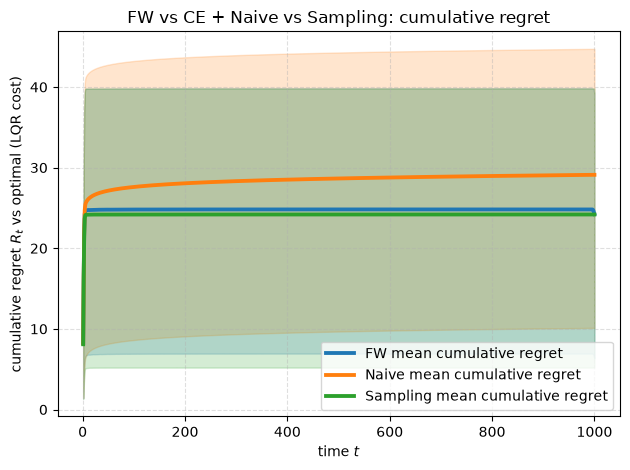

In [15]:


def main_single_run(seed=1, run_naive=True):
    
    # ======================================================================
    # True system & setup parameters
    # ======================================================================
    rng = np.random.default_rng(seed)
    #A_true = np.array([[1.0, 1.0],
     #                  [0.0, 0.9]], dtype=np.float64)
    A_true = np.array([[1.2, 1.0],
                       [0.0, 1.0]], dtype=np.float64)
    B_true = np.array([[0.0],
                       [1.0]], dtype=np.float64)
    n, m = B_true.shape

    noise_std = 0.3
    Sigma_w = (noise_std**2) * np.eye(n, dtype=np.float64)
    x0 = rng.normal(size=(n,)).astype(np.float64)

    T, K_episodes = 1000, 20
    M = 100
    Q_lqr = np.eye(n, dtype=np.float64)
    R_lqr = np.eye(m, dtype=np.float64)
    W_base = block_diag_np(Q_lqr, R_lqr)
    G = np.eye(n + m, dtype=np.float64)

    # old \tau interval ------------------------------------------------
    #tau = np.linspace(0, T, K_episodes + 1, dtype=int)

    # new \tau interval -------------------------------------------------
    # More frequent updates early, less frequent updates later, since explorations are emphasized early on
    alpha = 1.7  # larger alpha => more front-loaded updates
    
    grid = np.linspace(0.0, 1.0, K_episodes + 1)
    tau = np.round(T * grid**alpha).astype(int)
    
    # Ensure valid, strictly increasing update times.
    tau[0] = 0
    tau[-1] = T
    tau = np.maximum.accumulate(tau)
    
    # Fix possible duplicates caused by rounding.
    for i in range(1, len(tau)):
        if tau[i] <= tau[i - 1]:
            tau[i] = tau[i - 1] + 1
    
    tau[-1] = T


    # ======================================================================
    # Optimal average per-step baseline: T J_star
    # ======================================================================
    _, K_star = riccati_iteration(A_true, B_true, Q_lqr, R_lqr)
    Sigma_x0_initial = np.outer(x0, x0).astype(np.float64)
    Acl_star = A_true - B_true @ K_star
    Sigma_star = solve_discrete_lyapunov_np(Acl_star.T, Sigma_w)
    J_star = float(np.trace((Q_lqr + K_star.T @ R_lqr @ K_star) @ Sigma_star))

    c_opt_t = np.full(T, J_star, dtype=np.float64)
    cum_opt = np.arange(1, T + 1, dtype=np.float64) * J_star

    # ======================================================================
    # Initial priors
    # ======================================================================
    probe_horizon = 50
    # FIX: restore the smallest probe scale that avoided catastrophic divergence.
    sigma_probe = 0.3
    K_stab = np.zeros((m, n))

    def rollout_with_probe(K_stab, x0, T, sigma_p, rng_probe):
        x = x0.copy()
        xs = []
        xus = []
        for _t in range(T):
            eta = sigma_p * rng_probe.normal(size=(m,)).astype(x.dtype)
            u = -K_stab @ x + eta
            noise_std_prior =0.4
            w = noise_std_prior * rng_probe.normal(size=(n,)).astype(x.dtype)
            x_next = A_true @ x + B_true @ u + w
            xu = np.concatenate([x, u])
            xs.append(x_next)
            xus.append(xu)
            x = x_next
        xs = np.asarray(xs, dtype=x0.dtype)
        xus = np.asarray(xus, dtype=x0.dtype)
        cov = (xus.T @ xus) / T
        cross_cov = (xs.T @ xus) / T
        return cov, cross_cov

    rng_probe = np.random.default_rng(1 + seed)
    S_xu_init, S_xxu_init = rollout_with_probe(K_stab, x0, probe_horizon, sigma_probe, rng_probe)
    AB_hat_init = S_xxu_init @ np.linalg.pinv(S_xu_init)
    A_hat_init, B_hat_init = AB_hat_init[:, :n], AB_hat_init[:, n:]
    
    # ======================================================================
    # Frank-Wolfe approach 
    # ======================================================================
    S_xu, S_xxu = S_xu_init.copy(), S_xxu_init.copy()
    A_hat, B_hat = A_hat_init.copy(), B_hat_init.copy()
    Sigma_x0_FW = Sigma_x0_initial.copy()
    regret_steps_FW = []

    for k in range(K_episodes):
        H_horizon = int(T - int(tau[k]))
        H_hat = np.eye(n * (n + m), dtype=np.float64)
        

        S_list_beta = track_cumulative_covariances_naive_policy(
            A_hat, B_hat,          # synthesize K on estimates
            A_hat, B_hat,          # predicted rollout under estimated dynamics
            Sigma_w, Sigma_x0_FW,
            H_horizon, m,
            int(tau[k]),
            Q_lqr, R_lqr,
            finite_horizon=True,  
            explore_scale=0.1     # match the actual Naive baseline
        )

        tau_remaining = tau[k:] - tau[k]
        K_info = max(len(tau_remaining) - 2, 0)

        beta = compute_objective_tau0(
            S_list_beta,
            tau_remaining,
            K_info,
            Q_lqr, R_lqr, H_hat, S_xu, Sigma_w
        )
        Lambda = S_xu
        X_opt, policies = frank_wolfe(
            A=A_hat, B=B_hat, Lambda=Lambda, beta=beta, Sigma_w=Sigma_w, M_steps=M,
            make_costs_fn=make_costs_fun, solve_subproblem_fn=solve_subproblem,
            W_base=W_base, H_hat=H_hat, tau=tau, k=k, T=T,
            Sigma_x0=Sigma_x0_FW  
        )

        # Remark 2 samples search point j with 2(j+1)/(M(M+1)).
        L = len(policies)
        mixture_weights = 2.0 * (np.arange(L) + 1.0) / (L * (L + 1.0))
        pick_rng = np.random.default_rng(seed * 12 + k)
        j = int(pick_rng.choice(L, p=mixture_weights))
        K_seq = policies[j]

        ep_len = int(tau[k + 1]) - int(tau[k])
        cov_sum, cross_cov, Sigma_x0_FW, c_FW_k, Z_stack = rollout_combined(
            K_seq[0:ep_len],
            A_true, B_true, Sigma_w, Sigma_x0_FW,
            int(tau[k]), int(tau[k + 1]),
            Q_lqr=Q_lqr, R_lqr=R_lqr
        )

        c_opt_slice = c_opt_t[int(tau[k]):int(tau[k + 1])]
        regret_steps_FW.append(c_FW_k - c_opt_slice)

        S_xu = S_xu + cov_sum
        S_xxu = S_xxu + cross_cov
        AB_hat = S_xxu @ np.linalg.pinv(S_xu)
        A_hat, B_hat = AB_hat[:, :n], AB_hat[:, n:]

    regret_steps_FW = np.concatenate(regret_steps_FW, axis=0)
    cum_regret_FW = np.cumsum(regret_steps_FW)
    total_regret_FW = float(cum_regret_FW[-1])
    print("episodic_total_regret (FW):", total_regret_FW)

    # ======================================================================
    # CE with naive explorations approach
    # ======================================================================
    cum_naive_regret = None
    if run_naive:
        S_xu_naive, S_xxu_naive = S_xu_init.copy(), S_xxu_init.copy()
        A_hat_naive, B_hat_naive = A_hat_init.copy(), B_hat_init.copy()
        Sigma_x0_naive = Sigma_x0_initial.copy()

        c_naive_t = np.zeros((T,), dtype=np.float64)

        for k in range(K_episodes):
            ep_len = int(tau[k + 1] - tau[k])

            S_naive_list_k, Sigma_x0_naive = _naive_policy_covariances_with_final(
                A_hat_naive, B_hat_naive,
                A_true, B_true,
                Sigma_w, Sigma_x0_naive,
                ep_len, m,
                int(tau[k]),
                Q_lqr, R_lqr
            )

            S_naive_stack_k = np.stack(S_naive_list_k, axis=0)
            S_naive_prev_k = np.concatenate([np.zeros_like(S_naive_stack_k[:1]), S_naive_stack_k[:-1]], axis=0)
            Z_naive_k = S_naive_stack_k - S_naive_prev_k
            c_naive_k = np.einsum('ab,tba->t', W_base, Z_naive_k)
            c_naive_t[int(tau[k]):int(tau[k + 1])] = c_naive_k

            Sigma_zz_ep = S_naive_stack_k[-1]
            S_xu_naive = S_xu_naive + Sigma_zz_ep

            # Preserve the existing Naive prior update style from the notebook.
            A_concat_true = np.concatenate([A_true, B_true], axis=1)
            S_xxu_naive = S_xxu_naive + A_concat_true @ Sigma_zz_ep
            AB_hat_naive = S_xxu_naive @ np.linalg.pinv(S_xu_naive)
            A_hat_naive, B_hat_naive = AB_hat_naive[:, :n], AB_hat_naive[:, n:]

        cum_naive = np.cumsum(c_naive_t)
        cum_naive_regret = cum_naive - cum_opt


    # ======================================================================
    # Sampling-based gain perturbation approach
    # ======================================================================
    # This baseline is method-symmetric: it starts from the same probe data,
    # but maintains its own covariance, data matrices, and model estimates.
    S_xu_sampling, S_xxu_sampling = S_xu_init.copy(), S_xxu_init.copy()
    A_hat_sampling, B_hat_sampling = A_hat_init.copy(), B_hat_init.copy()
    Sigma_x0_sampling = Sigma_x0_initial.copy()
    c_sampling_t = np.zeros((T,), dtype=np.float64)

    for k in range(K_episodes):
        H_horizon = int(T - int(tau[k]))
        ep_len = int(tau[k + 1] - tau[k])
        tau_remaining = tau[k:] - tau[k]
        H_hat = np.eye(n * (n + m), dtype=np.float64)

        # Claude's reconstruction: CE gain + 30 N(0, 0.1^2) perturbations;
        # choose the candidate with the smallest corrected objective (19).
        rng_sampling = np.random.default_rng(seed * 977 + 31 * k + 5)
        K_sampling, _sampling_objectives = select_sampling_gain(
            A_hat_sampling, B_hat_sampling,
            Sigma_w, Sigma_x0_sampling,
            H_horizon, tau_remaining,
            Q_lqr, R_lqr, H_hat, S_xu_sampling,
            rng_sampling,
            num_perturbations=30,
            perturbation_scale=0.1,
        )

        K_sampling_seq = np.repeat(K_sampling[None, :, :], ep_len, axis=0)
        cov_sum, cross_cov, Sigma_x0_sampling, c_sampling_k, _ = rollout_combined(
            K_sampling_seq,
            A_true, B_true, Sigma_w, Sigma_x0_sampling,
            int(tau[k]), int(tau[k + 1]),
            Q_lqr=Q_lqr, R_lqr=R_lqr,
        )
        c_sampling_t[int(tau[k]):int(tau[k + 1])] = c_sampling_k

        S_xu_sampling = S_xu_sampling + cov_sum
        S_xxu_sampling = S_xxu_sampling + cross_cov
        AB_hat_sampling = S_xxu_sampling @ np.linalg.pinv(S_xu_sampling)
        A_hat_sampling = AB_hat_sampling[:, :n]
        B_hat_sampling = AB_hat_sampling[:, n:]

    cum_sampling_regret = np.cumsum(c_sampling_t - c_opt_t)
    print("episodic_total_regret (Sampling):", float(cum_sampling_regret[-1]))

    return (
        float(cum_regret_FW[-1]),
        cum_regret_FW,
        cum_naive_regret,
        cum_sampling_regret,
    )



def _run_one_trial_for_mc(trial):
    """
    One Monte Carlo trial wrapper.
    """
    R_fw, cum_regret_FW, cum_naive_regret, cum_sampling_regret = main_single_run(
        seed=trial + 5,
        run_naive=True
    )
    
    if cum_naive_regret is None:
        raise RuntimeError("Naive regret is None; ensure run_naive=True.")
    if cum_sampling_regret is None:
        raise RuntimeError("Sampling regret is None.")
    return R_fw, cum_regret_FW, cum_naive_regret, cum_sampling_regret


def _save_current_figure_tikz(tikz_path):
    """Save the current Matplotlib figure as a TikZ/PGFPlots file."""
    if tikz_path is None:
        return

    import os
    os.makedirs(os.path.dirname(tikz_path) or ".", exist_ok=True)
    try:
        import tikzplotlib
        tikzplotlib.save(tikz_path)
        print(f"Saved TikZ figure to {tikz_path}")
    except Exception as exc:
        print(f"Could not save TikZ figure to {tikz_path}: {exc}")
        print("Install tikzplotlib if you want automatic .tex figure export.")


def main_multiple_runs(num_trials=10, parallel=True, max_workers=None,
                       tikz_path="tikz_figures/experiment_c_cumulative_regret.tex"):
    """
    Monte Carlo wrapper with optional parallel execution.
    Curves:
      - FW mean + 10--90 percentile band
      - Naive mean + 10--90 percentile band
      - Sampling mean + 10--90 percentile band
    """
    import numpy as np
    trial_indices = list(range(num_trials))

    if parallel and num_trials > 1:
        import os
        import multiprocessing as mp
        from concurrent.futures import ProcessPoolExecutor

        if max_workers is None:
            max_workers = min(num_trials, os.cpu_count() or 1)

        print(f"Running {num_trials} Monte Carlo trials in parallel with max_workers={max_workers}.")

        try:
            ctx = mp.get_context("fork")
        except Exception:
            ctx = None

        try:
            if ctx is not None:
                with ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) as executor:
                    results = list(executor.map(_run_one_trial_for_mc, trial_indices))
            else:
                with ProcessPoolExecutor(max_workers=max_workers) as executor:
                    results = list(executor.map(_run_one_trial_for_mc, trial_indices))
        except Exception as e:
            print("Parallel execution failed; falling back to serial execution.")
            print("Reason:", repr(e))
            results = []
            for trial in trial_indices:
                print(f"Trial {trial + 1}/{num_trials}")
                results.append(_run_one_trial_for_mc(trial))
    else:
        results = []
        for trial in trial_indices:
            print(f"Trial {trial + 1}/{num_trials}")
            results.append(_run_one_trial_for_mc(trial))

    total_regrets_fw = []
    total_regrets_naive = []
    total_regrets_sampling = []
    cum_regret_trials_fw = []
    cum_regret_trials_naive = []
    cum_regret_trials_sampling = []

    for trial, (R_fw, cum_regret_FW, cum_naive_regret, cum_sampling_regret) in enumerate(results):
        print(f"Finished trial {trial + 1}/{num_trials}")

        total_regrets_fw.append(float(R_fw))
        cum_regret_trials_fw.append(cum_regret_FW)

        total_regrets_naive.append(float(cum_naive_regret[-1]))
        cum_regret_trials_naive.append(cum_naive_regret)

        total_regrets_sampling.append(float(cum_sampling_regret[-1]))
        cum_regret_trials_sampling.append(cum_sampling_regret)


    total_regrets_fw = np.asarray(total_regrets_fw)
    total_regrets_naive = np.asarray(total_regrets_naive)
    total_regrets_sampling = np.asarray(total_regrets_sampling)

    cum_regret_trials_fw = np.stack(cum_regret_trials_fw, axis=0)
    cum_regret_trials_naive = np.stack(cum_regret_trials_naive, axis=0)
    cum_regret_trials_sampling = np.stack(cum_regret_trials_sampling, axis=0)

    Rt_fw_mean = np.mean(cum_regret_trials_fw, axis=0)
    Rt_naive_mean = np.mean(cum_regret_trials_naive, axis=0)
    Rt_sampling_mean = np.mean(cum_regret_trials_sampling, axis=0)

    fw_p10 = np.percentile(cum_regret_trials_fw, 10, axis=0)
    fw_p90 = np.percentile(cum_regret_trials_fw, 90, axis=0)

    naive_p10 = np.percentile(cum_regret_trials_naive, 10, axis=0)
    naive_p90 = np.percentile(cum_regret_trials_naive, 90, axis=0)

    sampling_p10 = np.percentile(cum_regret_trials_sampling, 10, axis=0)
    sampling_p90 = np.percentile(cum_regret_trials_sampling, 90, axis=0)


    avg_regret_fw = float(np.mean(total_regrets_fw))
    std_regret_fw = float(np.std(total_regrets_fw))
    avg_regret_naive = float(np.mean(total_regrets_naive))
    std_regret_naive = float(np.std(total_regrets_naive))
    avg_regret_sampling = float(np.mean(total_regrets_sampling))
    std_regret_sampling = float(np.std(total_regrets_sampling))

    import matplotlib.pyplot as plt

    Tlen = Rt_fw_mean.shape[0]
    t_grid = np.arange(1, Tlen + 1)

    fig = plt.figure()

    fw_line, = plt.plot(t_grid, Rt_fw_mean, linewidth=2.75, label="FW mean cumulative regret")
    plt.fill_between(t_grid, fw_p10, fw_p90, alpha=0.20, color=fw_line.get_color())

    naive_line, = plt.plot(t_grid, Rt_naive_mean, linewidth=2.75, label="Naive mean cumulative regret")
    plt.fill_between(t_grid, naive_p10, naive_p90, alpha=0.20, color=naive_line.get_color())

    sampling_line, = plt.plot(t_grid, Rt_sampling_mean, linewidth=2.75, label="Sampling mean cumulative regret")
    plt.fill_between(t_grid, sampling_p10, sampling_p90, alpha=0.20,
                     color=sampling_line.get_color())


    plt.xlabel("time $t$")
    plt.ylabel("cumulative regret $R_t$ vs optimal (LQR cost)")
    plt.title("FW vs CE + Naive vs Sampling: cumulative regret")
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    _save_current_figure_tikz(tikz_path)

    print(f"FW       average_total_regret: {avg_regret_fw:.4f}  std: {std_regret_fw:.4f}")
    print(f"Naive    average_total_regret: {avg_regret_naive:.4f}  std: {std_regret_naive:.4f}")
    print(f"Sampling average_total_regret: {avg_regret_sampling:.4f}  std: {std_regret_sampling:.4f}")

    return (
        (avg_regret_fw, std_regret_fw),
        (avg_regret_naive, std_regret_naive),
        (avg_regret_sampling, std_regret_sampling),
    )


if __name__ == "__main__":
    main_multiple_runs(num_trials=4, parallel=True)
